# Prueba Final - Ciencia de Datos

## Descripción
EduTech Analytics es una plataforma de educación en línea que ofrece cursos de tecnología y ciencia de datos. La empresa ha recopilado información detallada de 500 estudiantes durante el último año académico y necesita desarrollar un sistema integral de análisis que permita:


*   Predecir la probabilidad de que un estudiante complete exitosamente un curso
*   Estimar el puntaje de satisfacción final que otorgará cada estudiante
*   Identificar patrones de comportamiento que influyen en el éxito académico
*   Generar recomendaciones basadas en datos para mejorar la retención estudiantil


Como Científico de Datos, deberás aplicar todo el ciclo de análisis: desde la exploración y preparación de datos hasta la construcción, optimización y evaluación de modelos predictivos, incluyendo el procesamiento a escala con Apache Spark.

## Parte 1: Análisis Exploratorio y Visualización (3 puntos)

1.1 Exploración Inicial con Pandas y NumPy (1 punto)

,id_estudiante,nombre,edad,genero,pais,horas_estudio_semanal,sesiones_totales,tareas_completadas,tareas_totales,participacion_foros,promedio_evaluaciones,dispositivo_principal,horario_estudio,nivel_educacion,experiencia_previa,monto_inversion,plataforma_origen,curso_completado,puntaje_satisfaccion
0,1,Estudiante_1,56,Otro,Argentina,16,10,31,50,57,64.25,Mobile,Noche,Posgrado,Sí,879,Google,0,4.4
1,2,Estudiante_2,46,Femenino,Colombia,24,76,28,50,20,59.26,Tablet,Noche,Pregrado,No,1959,Google,0,3.4
2,3,Estudiante_3,32,Masculino,Colombia,19,94,42,50,81,84.99,Tablet,Tarde,Pregrado,No,2631,Google,1,9.6
3,4,Estudiante_4,60,Otro,México,8,105,1,50,68,64.76,Desktop,Tarde,Posgrado,No,741,Google,0,4.9
4,5,Estudiante_5,25,Femenino,Colombia,31,1,22,50,2,78.77,Tablet,Tarde,Pregrado,No,4069,Directo,0,4.8
5,6,Estudiante_6,38,Otro,Perú,21,133,18,50,86,78.79,Tablet,Mañana,Pregrado,Sí,981,Facebook,0,5.5
6,7,Estudiante_7,56,Masculino,Perú,17,20,30,50,89,93.28,Mobile,Mañana,Secundaria,No,4986,Facebook,0,8.3
7,8,Estudiante_8,36,Masculino,Chile,23,8,50,50,36,75.92,Mobile,Tarde,Posgrado,Sí,3456,Referido,1,7.2
8,9,Estudiante_9,40,Masculino,Perú,37,171,4,50,87,70.13,Desktop,Tarde,Posgrado,Sí,197,Facebook,0,6.0
9,10,Estudiante_10,28,Otro,Perú,16,1,18,50,48,48.33,Mobile,Mañana,Posgrado,No,1082,Facebook,0,4.0


,id_estudiante,edad,horas_estudio_semanal,sesiones_totales,tareas_completadas,tareas_totales,participacion_foros,promedio_evaluaciones,monto_inversion,curso_completado,puntaje_satisfaccion
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0,500.000000,500.000000,500.000000,500.00000,500.000000
mean,250.500000,41.980000,20.902000,99.658000,25.264000,50.0,49.778000,71.159940,2508.956000,0.14600,5.359800
std,144.481833,13.800598,11.312486,58.079527,14.359202,0.0,28.892807,17.358748,1467.201453,0.35346,1.728496
min,1.000000,18.000000,1.000000,1.000000,0.000000,50.0,0.000000,40.030000,61.000000,0.00000,1.000000
25%,125.750000,31.000000,12.000000,48.000000,14.000000,50.0,25.000000,56.030000,1213.250000,0.00000,4.200000
50%,250.500000,43.000000,20.500000,102.000000,24.500000,50.0,48.000000,72.140000,2413.500000,0.00000,5.300000
75%,375.250000,53.000000,31.000000,149.250000,38.000000,50.0,75.000000,85.772500,3876.250000,0.00000,6.500000
max,500.000000,65.000000,40.000000,200.000000,50.000000,50.0,100.000000,99.980000,4992.000000,1.00000,10.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_estudiante          500 non-null    int64  
 1   nombre                 500 non-null    object 
 2   edad                   500 non-null    int64  
 3   genero                 500 non-null    object 
 4   pais                   500 non-null    object 
 5   horas_estudio_semanal  500 non-null    int64  
 6   sesiones_totales       500 non-null    int64  
 7   tareas_completadas     500 non-null    int64  
 8   tareas_totales         500 non-null    int64  
 9   participacion_foros    500 non-null    int64  
 10  promedio_evaluaciones  500 non-null    float64
 11  dispositivo_principal  500 non-null    object 
 12  horario_estudio        500 non-null    object 
 13  nivel_educacion        500 non-null    object 
 14  experiencia_previa     500 non-null    object 
 15  monto_

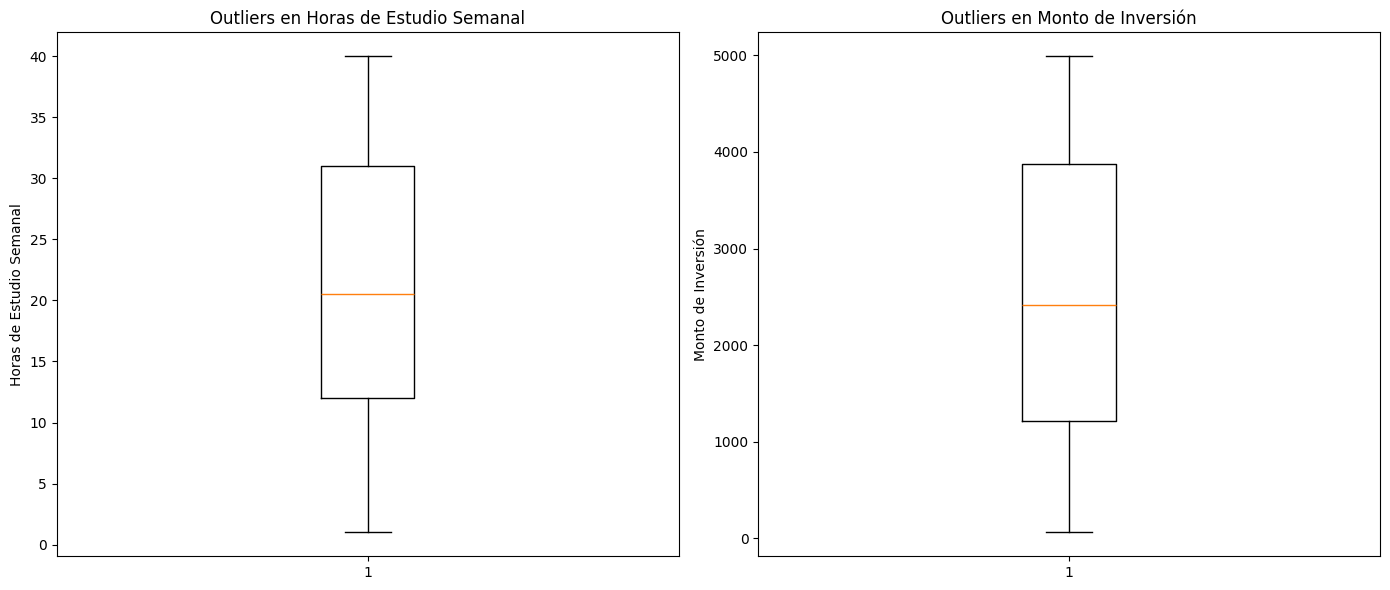


No se observan para estas variables outliers


In [ ]:
# ● Carga el dataset y muestra las primeras 10 filas

import numpy as np
import pandas as pd

df = pd.read_csv('/content/02. Material de apoyo - Estudiantes_edutech.csv')
display(df.head(10))

# ● Genera estadísticas descriptivas completas de las variables numéricas
print()
display(df.describe())


# ● Identifica y maneja valores nulos o inconsistentes

print(df.info()) # No se identifican valores nulos

print()
# ● Calcula la correlación entre variables numéricas usando NumPy

# Seleccionar todas las numericas menos Tareas totales, edad y id
num_df = df.select_dtypes(include=[np.number])
if 'tareas_totales' in num_df.columns:
    num_df = num_df.drop(columns=['tareas_totales', "edad", "id_estudiante"])

corr = np.corrcoef(num_df, rowvar=False)

# ● Identifica outliers en horas_estudio_semanal y monto_inversion

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].boxplot(df['horas_estudio_semanal'])
axes[0].set_title('Outliers en Horas de Estudio Semanal')
axes[0].set_ylabel('Horas de Estudio Semanal')

axes[1].boxplot(df['monto_inversion'])
axes[1].set_title('Outliers en Monto de Inversión')
axes[1].set_ylabel('Monto de Inversión')

plt.tight_layout()
plt.show()
print("\nNo se observan para estas variables outliers")

1.2 Visualización Avanzada con Seaborn (1 punto)

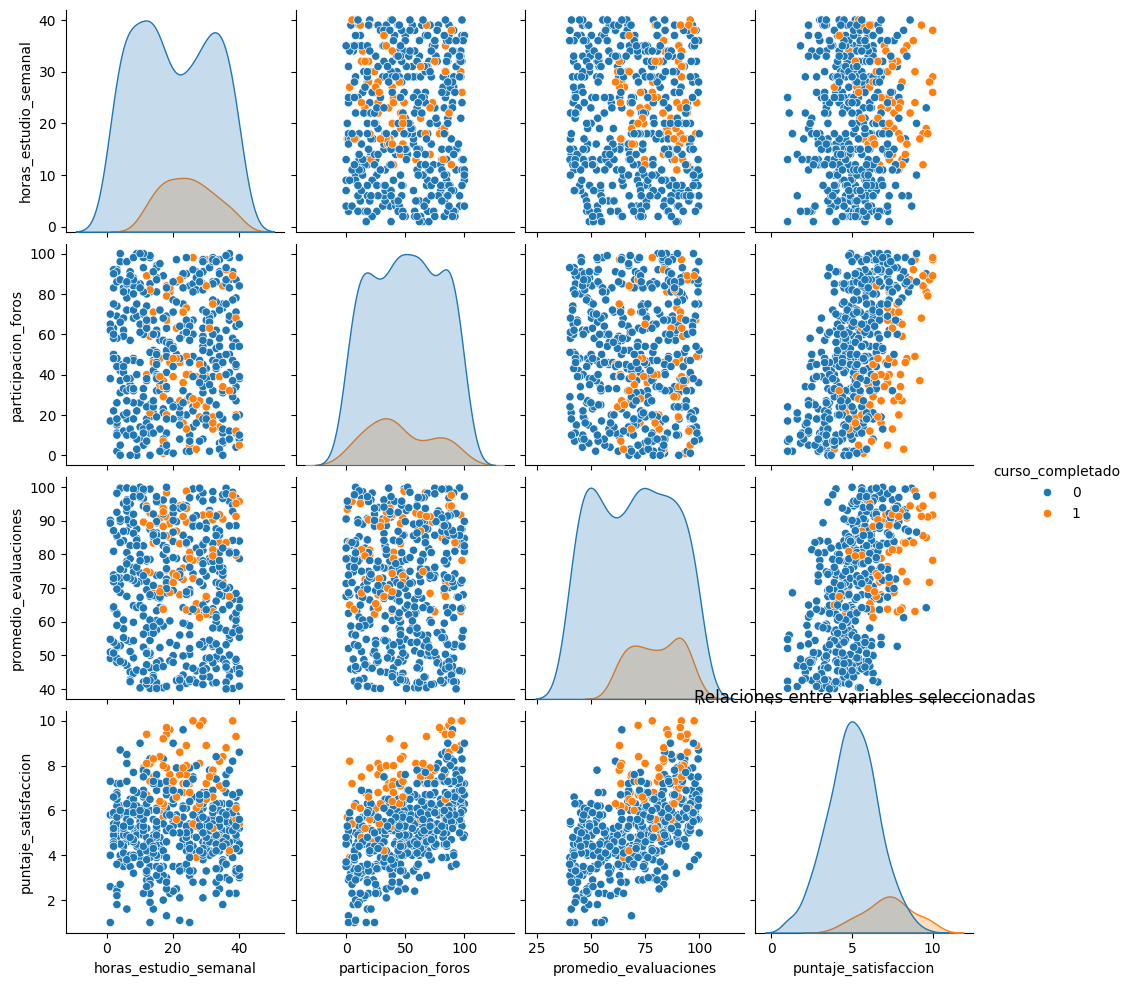

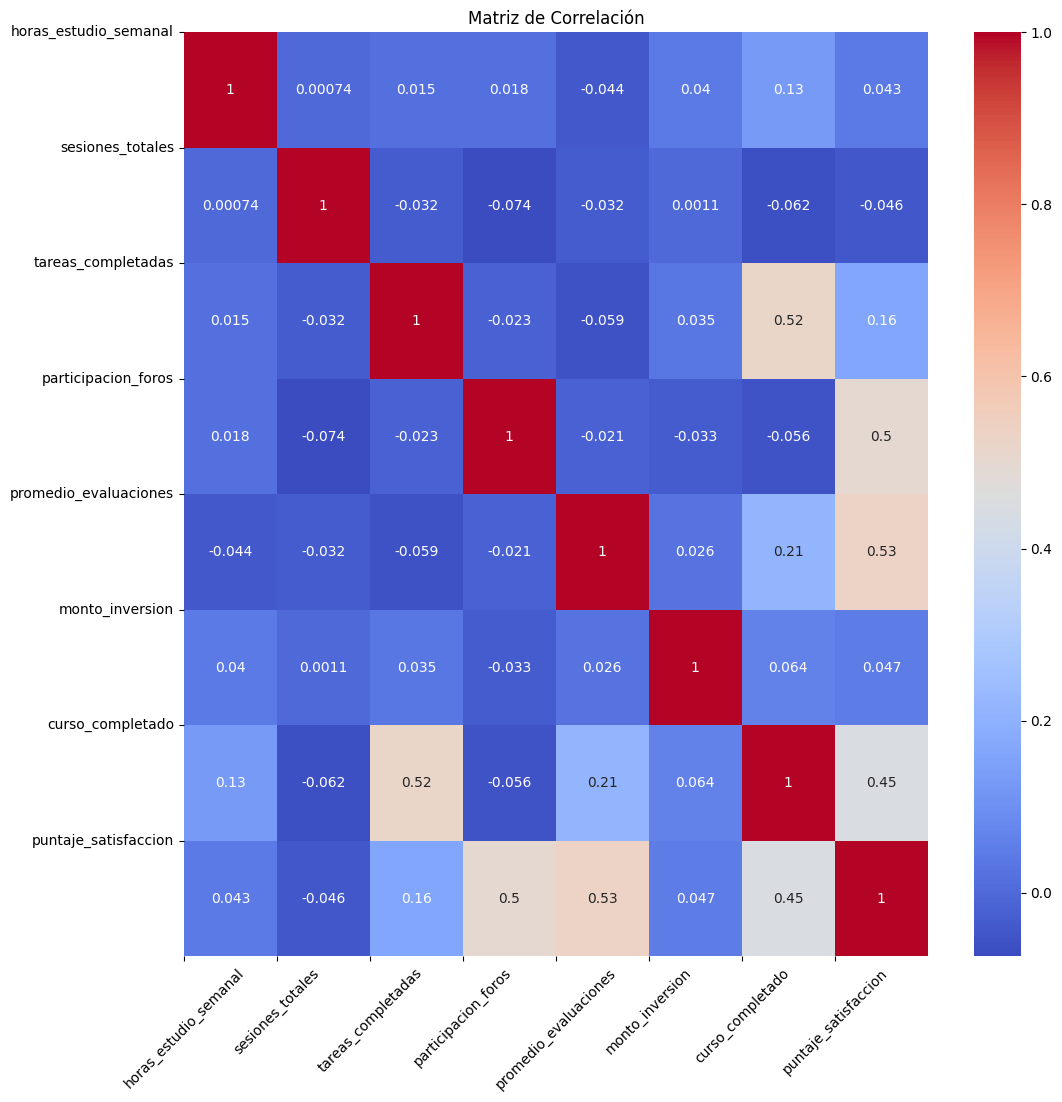

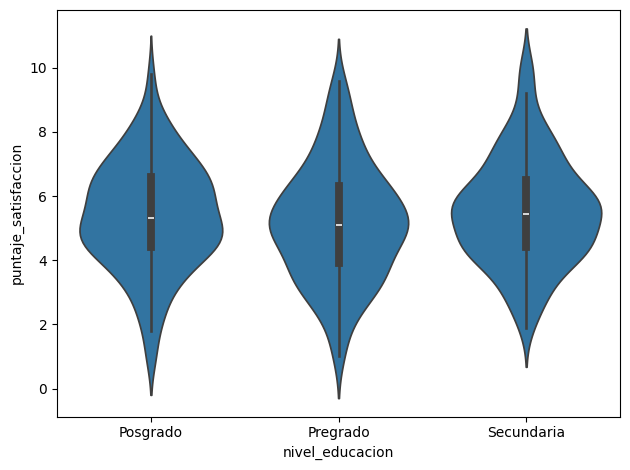

In [ ]:
#Crea un pairplot que muestre las relaciones entre horas_estudio_semanal, participacion_foros, promedio_evaluaciones y puntaje_satisfaccion, diferenciando por curso_completado

import seaborn as sns

sns.pairplot(df, hue='curso_completado', vars=['horas_estudio_semanal', 'participacion_foros', 'promedio_evaluaciones', 'puntaje_satisfaccion'])
plt.title('Relaciones entre variables seleccionadas')
plt.show()

# ● Genera un heatmap de la matriz de correlación de todas las variables numéricas
print()
plt.figure(figsize=(12, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.xticks(range(len(num_df.columns)), num_df.columns, rotation=45)
plt.yticks(range(len(num_df.columns)), num_df.columns, rotation=0, va = "center")
plt.title('Matriz de Correlación')
plt.show()

# ● Construye un violinplot comparando la distribución de puntaje_satisfaccion por nivel_educacion
print()
sns.violinplot(x='nivel_educacion', y='puntaje_satisfaccion', data=df)
plt.tight_layout()
plt.show()


1.3 Personalización con Matplotlib (1 punto)

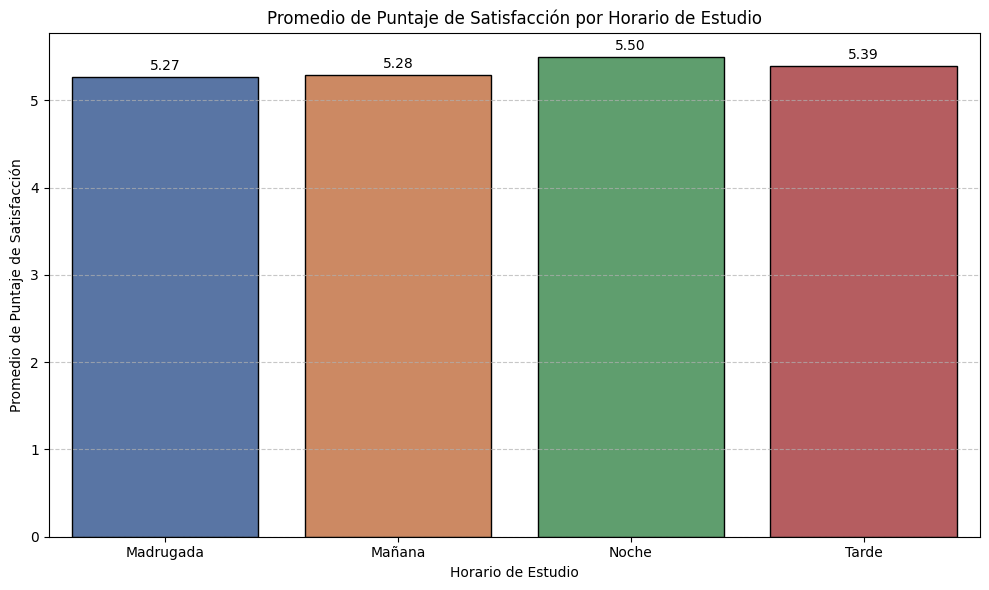

In [ ]:
# Crea un gráfico de barras que muestre el promedio de puntaje_satisfaccion por horario_estudio
# ● Personaliza el gráfico con:
#  ○ Título descriptivo y etiquetas de ejes
#  ○ Colores personalizados (paleta a elección)
#  ○ Anotaciones con los valores exactos sobre cada barra
#  ○ Grid horizontal para facilitar lectura
#  ○ Bordes en las barras

# Calculate the mean satisfaction for each study schedule
mean_satisfaction_by_horario = df.groupby('horario_estudio')['puntaje_satisfaccion'].mean().reset_index()

plt.figure(figsize=(10, 6))

ax = sns.barplot(x='horario_estudio',
                 y='puntaje_satisfaccion',
                 data=mean_satisfaction_by_horario,
                 palette="deep",
                 edgecolor="black",
                 hue='horario_estudio',
                 legend=False)

plt.title('Promedio de Puntaje de Satisfacción por Horario de Estudio')
plt.xlabel('Horario de Estudio')
plt.ylabel('Promedio de Puntaje de Satisfacción')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Etiquetas a las barras
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()


# ● Guarda el gráfico como satisfaccion_horario.png

plt.savefig("satisfaccion_horario.png")

plt.show()

## Parte 2: Preparación de Datos y Feature Engineering (2 puntos)

2.1 Transformación de Variables (1 punto)

In [ ]:
import numpy as np
import pandas as pd

# ● Crea una nueva variable tasa_completitud = (tareas_completadas / tareas_totales) * 100

df["tasa_completitud"] = (df['tareas_completadas'] / df['tareas_totales']) * 100

# ● Genera variable binaria estudiante_activo = 1 si sesiones_totales > 50, sino 0

df['estudiante_activo'] = np.where(df['sesiones_totales'] > 50, 1, 0)

# ● Codifica variables categóricas usando LabelEncoder para variables ordinales y OneHotEncoder para nominales
# ● Normaliza las variables numéricas usando StandardScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

var_cat_ord = ['nivel_educacion', 'horario_estudio', 'experiencia_previa'] # Curso completado ya es una variable binaria
var_cat_nom = ['genero', "pais", "dispositivo_principal", "plataforma_origen"]
var_num = ['horas_estudio_semanal', "sesiones_totales", 'participacion_foros', 'promedio_evaluaciones', 'tasa_completitud'] # Tareas completadas y Tareas totales quedan incluidos en la var tasa_completitud, y puntaje_satisfaccion fue removida ya que es la variable objetivo de regresion

preprocesor = ColumnTransformer([
    ('cat_ord', OrdinalEncoder(), var_cat_ord),
    ('cat_nom', OneHotEncoder(drop='first', sparse_output= False), var_cat_nom),
    ('num', StandardScaler(), var_num)
], remainder='passthrough')

2.2 División y Preparación (1 punto)

In [ ]:
# ● Separa features (X) y variables objetivo (y_clasificacion: curso_completado, y_regresion: puntaje_satisfaccion)
# ● Divide los datos en entrenamiento (70%) y prueba (30%) con random_state=42

df_base = df.drop(columns=["id_estudiante", "nombre", "tareas_completadas", "tareas_totales"]) # Se dropean ya que no sirven en el df y ademas tenemos columnas calculadas de esas

X = df_base.drop(columns=['curso_completado', 'puntaje_satisfaccion'])
y_clasificacion = df_base['curso_completado']
y_regresion = df_base['puntaje_satisfaccion']

# ● Aplica SMOTE si existe desbalanceo en la variable curso_completado

# % de registros que si completaron el curso

count = df['curso_completado'].sum() / df['curso_completado'].count()
print(f"Porcentaje de alumnos que completaron el Curso: {count*100:.2f}%")
print("\nExiste un desbalanceo de clases, se aplicará SMOTE.")

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(X, y_clasificacion, test_size=0.3, random_state=42)

X_train_processed = preprocesor.fit_transform(X_train)

smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

count_s = y_train_resampled.sum() / y_train_resampled.count()
print(f"\nPorcentaje de alumnos que completaron el Curso con SMOTE: {count_s*100:.2f}%")

Porcentaje de alumnos que completaron el Curso: 14.60%

Existe un desbalanceo de clases, se aplicará SMOTE.

Porcentaje de alumnos que completaron el Curso con SMOTE: 50.00%


## Parte 3: Modelado Predictivo con Machine Learning (3 puntos)

3.1 Modelo de Clasificación (1.5 puntos)

Objetivo: Predecir si un estudiante completará el curso

In [ ]:
# ● Entrena dos modelos: RandomForestClassifier y LogisticRegression
# ● Utiliza GridSearchCV para optimizar hiperparámetros:

#  ○ RandomForest: n_estimators, max_depth, min_samples_split
# ● Aplica validación cruzada (cv=5)
# ● Reporta los mejores hiperparámetros para RF

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 4, 6]
}

model = RandomForestClassifier()
grid_search = GridSearchCV(model, param_grid, cv=5)
grid_search.fit(X_train_resampled, y_train_resampled)
print(f"Mejores Hiperparametros para RF: {grid_search.best_params_}")

#  ○ LogisticRegression: C, penalty
# ● Aplica validación cruzada (cv=5)
# ● Reporta los mejores hiperparámetros para LR

param_grid2 = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ["l1","l2"],
    'solver': ['liblinear'], # Para la compatibilidad con l1
    'max_iter': [1000]
}

model2 = LogisticRegression()
grid_search2 = GridSearchCV(model2, param_grid2, cv=5)
grid_search2.fit(X_train_resampled, y_train_resampled)
print(f"Mejores Hiperparametros para LR: {grid_search2.best_params_}")

# ● Evalúa con las siguientes métricas:
#  ○ Accuracy
#  ○ Precision, Recall, F1-Score
#  ○ ROC-AUC
#  ○ Matriz de confusión

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

print("Metricas para RF:")
y_pred = grid_search.predict(preprocesor.transform(X_test))
print(f"\nAccuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred)}")
print(confusion_matrix(y_test, y_pred))

print("\nMetricas para LR:")
y_pred2 = grid_search2.predict(preprocesor.transform(X_test))
print(f"\nAccuracy: {accuracy_score(y_test, y_pred2)}")
print(classification_report(y_test, y_pred2))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred2)}")
print(confusion_matrix(y_test, y_pred2))

# Compara ambos Modelos

print("""
Para RF el modelo no tiene falsos positivos (FP) pero para que la herramienta funcione debemos seleccionar aquella que tiene menos Falsos negativos (FN) que en este caso es del modelo de LR.
Es decir, como tiene 4 FP (modelo LR) significa que habian 4 personas que estimamos que completarian el curso pero no lo hicieron,
para RF, son 12 personas, lo que significa que estamos fallando en predecir a 8 personas (5% de la muestra) que necesitan mejoras en su proceso de aprendizaje.

En el valor de precision y ROC-AUC: interpreta esta diferencia
""")


Mejores Hiperparametros para RF: {'max_depth': 5, 'min_samples_split': 4, 'n_estimators': 50}
Mejores Hiperparametros para LR: {'C': 10, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
Metricas para RF:

Accuracy: 0.8933333333333333
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       119
           1       1.00      0.48      0.65        31

    accuracy                           0.89       150
   macro avg       0.94      0.74      0.79       150
weighted avg       0.91      0.89      0.88       150

ROC-AUC: 0.7419354838709677
[[119   0]
 [ 16  15]]

Metricas para LR:

Accuracy: 0.9066666666666666
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       119
           1       0.73      0.87      0.79        31

    accuracy                           0.91       150
   macro avg       0.85      0.89      0.87       150
weighted avg       0.92      0.91      0.91       150

ROC

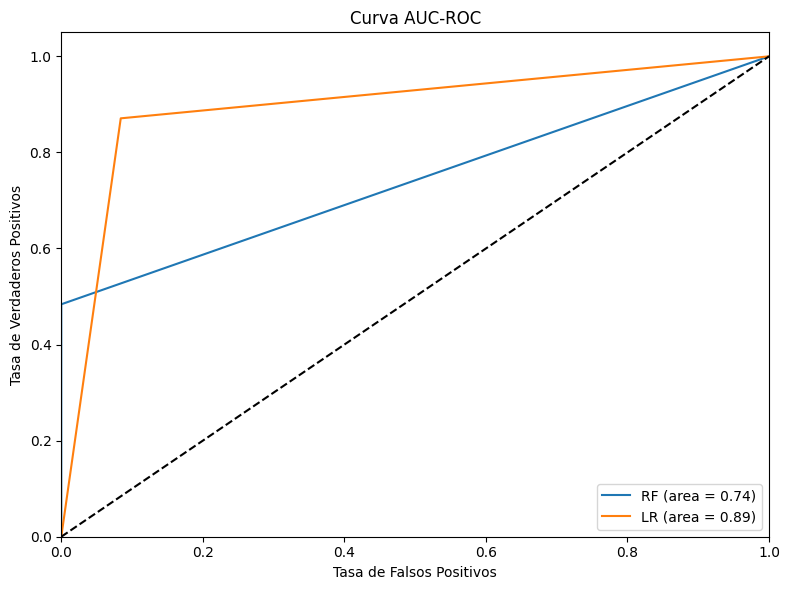

In [ ]:
# Curva AUC-ROC

from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 6))
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
fpr2, tpr2, thresholds2 = roc_curve(y_test, y_pred2)
plt.plot(fpr, tpr, label='RF (area = %0.2f)' % auc(fpr, tpr))
plt.plot(fpr2, tpr2, label='LR (area = %0.2f)' % auc(fpr2, tpr2))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva AUC-ROC')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


3.2 Modelo de Regresión (1.5 puntos)

Objetivo: Estimar el puntaje de satisfacción

Mejores Hiperparametros para RF: {'max_depth': 10, 'min_samples_split': 6, 'n_estimators': 50}
Mejores Hiperparametros para Ridge: {'alpha': 10, 'max_iter': 1000, 'solver': 'auto'}

Metricas para RF:

R2: 0.59
MAE: 0.91
RMSE: 1.16

Metricas para Ridge:

R2: 0.55
MAE: 0.98
RMSE: 1.21


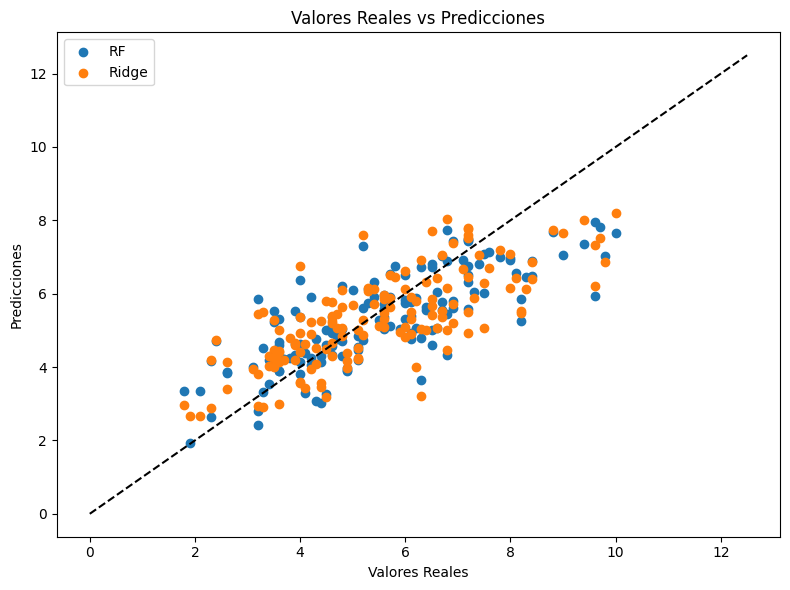

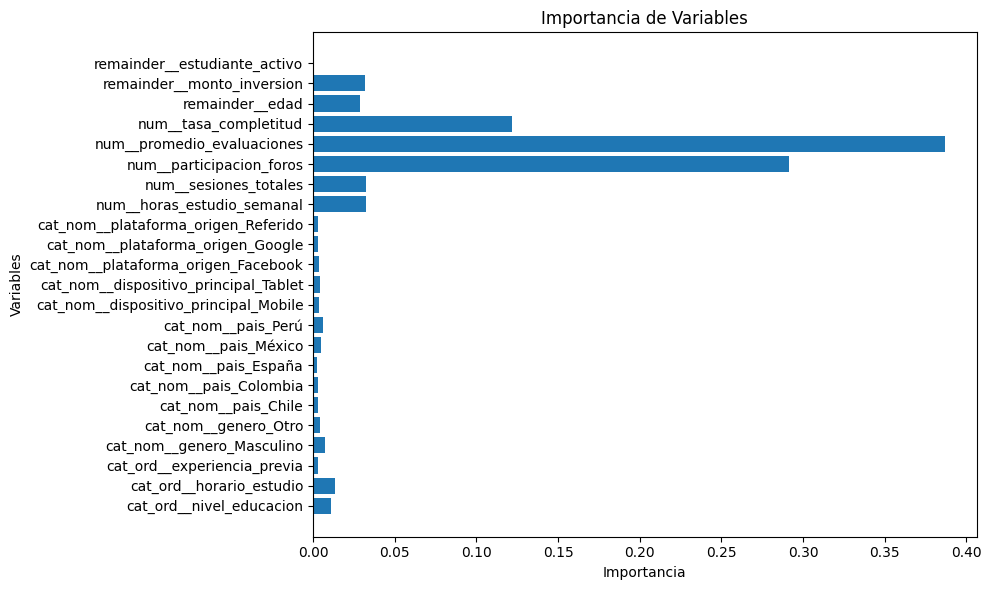

Variables mas importantes (top 5): ['num__promedio_evaluaciones' 'num__participacion_foros'
 'num__tasa_completitud' 'num__sesiones_totales'
 'num__horas_estudio_semanal']


In [ ]:
# ● Entrena dos modelos: RandomForestRegressor y Ridge
# ● Utiliza GridSearchCV para ajustar hiperparámetros
# ● Evalúa con:
#  ○ R² (coeficiente de determinación)
#  ○ MAE (Mean Absolute Error)
#  ○ RMSE (Root Mean Squared Error)

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.model_selection import train_test_split

X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y_regresion, test_size=0.3, random_state=42)
X_train_processed1 = preprocesor.fit_transform(X_train1)

# Modelo RFRegressor

model3 = RandomForestRegressor()
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 4, 6]
}

grid_search3 = GridSearchCV(model3, param_grid, cv=5)
grid_search3.fit(X_train_processed1, y_train1)
print(f"Mejores Hiperparametros para RF: {grid_search3.best_params_}")


# Modelo Ridge

model4 = Ridge()
param_grid2 = {
    'alpha': [0.01, 0.1, 1, 10],
    'solver': ['auto'],
    'max_iter': [1000]
}

grid_search4 = GridSearchCV(model4, param_grid2, cv=5)
grid_search4.fit(X_train_processed1, y_train1)
print(f"Mejores Hiperparametros para Ridge: {grid_search4.best_params_}")

print()

print("Metricas para RF:")
y_pred3 = grid_search3.predict(preprocesor.transform(X_test))
print(f"\nR2: {r2_score(y_test1, y_pred3):.2f}")
print(f"MAE: {mean_absolute_error(y_test1, y_pred3):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test1, y_pred3)):.2f}")

print("\nMetricas para Ridge:")
y_pred4 = grid_search4.predict(preprocesor.transform(X_test))
print(f"\nR2: {r2_score(y_test1, y_pred4):.2f}")
print(f"MAE: {mean_absolute_error(y_test1, y_pred4):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test1, y_pred4)):.2f}")

# ● Crea un gráfico de dispersión: valores reales vs predicciones

fig, ax = plt.subplots(figsize=(8, 6))
y_pred3 = grid_search3.predict(preprocesor.transform(X_test1))
y_pred4 = grid_search4.predict(preprocesor.transform(X_test1))
plt.scatter(y_test1, y_pred3, label='RF')
plt.scatter(y_test1, y_pred4, label='Ridge')
plt.plot([0, 12.5], [0, 12.5], 'k--')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Valores Reales vs Predicciones')
plt.legend()
plt.tight_layout()
plt.show()



# ● Identifica las 5 variables más importantes (feature importance)

mejor_modelo = grid_search3.best_estimator_
importancias = mejor_modelo.feature_importances_
nombres_columnas = preprocesor.get_feature_names_out()

print()

plt.figure(figsize=(10, 6))
plt.barh(nombres_columnas, importancias)
plt.xlabel('Importancia')
plt.ylabel('Variables')
plt.title('Importancia de Variables')
plt.tight_layout()
plt.show()

# Mostrar las 5 mas importantes
print(f"Variables mas importantes (top 5): {nombres_columnas[np.argsort(importancias)[-5:][::-1]]}")


## Parte 4: Procesamiento con Apache Spark MLlib (1.5 puntos)

4.1 Preparación en Spark (0.5 puntos)

In [ ]:
# ● Carga el dataset en un DataFrame de Spark

from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.sql.types import IntegerType

spark = SparkSession.builder \
    .appName("Estudiantes")\
    .getOrCreate()

df_csv = spark.read.option("header", True).option("inferSchema", True).option("sep", ",").csv("/content/02. Material de apoyo - Estudiantes_edutech.csv")

# ● Crea la columna label binaria para clasificación (curso_completado)

df_drop = df_csv.drop("id_estudiante", "nombre", "tareas_completadas", "tareas_totales", "puntaje_satisfaccion")

df_label = df_drop.withColumn("curso_completado", col("curso_completado").cast(IntegerType()))

# ● Aplica StringIndexer a variables categóricas
# ● Utiliza VectorAssembler para crear columna features
from pyspark.ml.feature import VectorAssembler, StringIndexer

esambladorTexto = StringIndexer(
    inputCols=['nivel_educacion', 'horario_estudio', 'experiencia_previa', 'genero', "pais", "dispositivo_principal", "plataforma_origen"],
    outputCols=['nivel_educacion_Index', 'horario_estudio_Index', 'experiencia_previa_Index',
                'genero_Index', "pais_Index", "dispositivo_principal_Index",
                "plataforma_origen_Index"]
    )

df_indexed = esambladorTexto.fit(df_label).transform(df_label)

# Define all features for VectorAssembler, aligning with pandas feature set
vector_assembler_input_cols = [
    'nivel_educacion_Index', 'horario_estudio_Index', 'experiencia_previa_Index',
    'genero_Index', "pais_Index", "dispositivo_principal_Index", "plataforma_origen_Index",
    'horas_estudio_semanal', "sesiones_totales", 'participacion_foros',
    'promedio_evaluaciones','edad', 'monto_inversion'
]

esamblador = VectorAssembler(
    inputCols=vector_assembler_input_cols,
    outputCol="features"
    )

df_vector = esamblador.transform(df_indexed)

# Normalizacion

from pyspark.ml.feature import StandardScaler
scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features", withMean=True, withStd=True
    )
scaler_model = scaler.fit(df_vector)
df_final = scaler_model.transform(df_vector)


df_final.printSchema()
df_final.show(5)

# ● Divide en train/test (70/30)
entrenamiento, prueba = df_final.randomSplit([0.7, 0.3], seed=2)


root
 |-- edad: integer (nullable = true)
 |-- genero: string (nullable = true)
 |-- pais: string (nullable = true)
 |-- horas_estudio_semanal: integer (nullable = true)
 |-- sesiones_totales: integer (nullable = true)
 |-- participacion_foros: integer (nullable = true)
 |-- promedio_evaluaciones: double (nullable = true)
 |-- dispositivo_principal: string (nullable = true)
 |-- horario_estudio: string (nullable = true)
 |-- nivel_educacion: string (nullable = true)
 |-- experiencia_previa: string (nullable = true)
 |-- monto_inversion: integer (nullable = true)
 |-- plataforma_origen: string (nullable = true)
 |-- curso_completado: integer (nullable = true)
 |-- nivel_educacion_Index: double (nullable = false)
 |-- horario_estudio_Index: double (nullable = false)
 |-- experiencia_previa_Index: double (nullable = false)
 |-- genero_Index: double (nullable = false)
 |-- pais_Index: double (nullable = false)
 |-- dispositivo_principal_Index: double (nullable = false)
 |-- plataforma_orig

4.2 Modelo en Spark (1 punto)

In [ ]:
# ● Entrena un modelo de clasificación: LogisticRegression o RandomForestClassifier
# ● Genera predicciones en el conjunto de prueba

from pyspark.ml.classification import RandomForestClassifier

modelo_rf = RandomForestClassifier(featuresCol= "scaled_features", labelCol='curso_completado', numTrees=4)
modelo_entrenado = modelo_rf.fit(entrenamiento)
predicciones = modelo_entrenado.transform(prueba)

# ● Evalúa el modelo con:
#  ○ BinaryClassificationEvaluator (areaUnderROC)
#  ○ MulticlassClassificationEvaluator (accuracy, f1)

from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# AUC-ROC
evaluator = BinaryClassificationEvaluator(labelCol='curso_completado')
area_bajo_curva = evaluator.evaluate(predicciones)
print(f"Area bajo la curva (AUC-ROC): {area_bajo_curva:.2f}")

# Accuracy y F1
accuracy_evaluator = MulticlassClassificationEvaluator(labelCol='curso_completado', metricName='accuracy')
f1_evaluator = MulticlassClassificationEvaluator(labelCol='curso_completado', metricName='f1')

# Calcular las métricas
accuracy = accuracy_evaluator.evaluate(predicciones)
f1_score = f1_evaluator.evaluate(predicciones)

# Resultados
print(f"\nAccuracy: {accuracy:.2f}")
print(f"F1-Score: {f1_score:.2f}")

# ● Muestra una tabla con las columnas: label, prediction, probability

predicciones.select("curso_completado", "prediction", "probability").show()


Area bajo la curva (AUC-ROC): 0.77

Accuracy: 0.86
F1-Score: 0.79
+----------------+----------+--------------------+
|curso_completado|prediction|         probability|
+----------------+----------+--------------------+
|               0|       0.0|[0.96183206106870...|
|               0|       0.0|[0.59897771111757...|
|               0|       0.0|[0.78571428571428...|
|               1|       0.0|[0.52256934280454...|
|               1|       0.0|[0.76953812316715...|
|               0|       0.0|[0.96183206106870...|
|               1|       0.0|[0.65393329189295...|
|               0|       0.0|[0.91546109332676...|
|               0|       0.0|[0.89191620879120...|
|               0|       0.0|[0.97142857142857...|
|               1|       0.0|[0.81220325373551...|
|               1|       0.0|[0.80260674337564...|
|               0|       0.0|[0.76262018423585...|
|               0|       0.0|[0.91546109332676...|
|               0|       0.0|[0.96183206106870...|
|               

## Parte 5: Inferencia Estadística (0.5 puntos)

In [ ]:
# ● Calcula el intervalo de confianza al 95% para la media de puntaje_satisfaccion
# ● Realiza una prueba de hipótesis para determinar si el puntaje promedio de satisfacción de estudiantes que completan el curso es significativamente diferente del de quienes no lo completan
#  ○ Plantea H₀ y H₁

print("H₀: El puntaje promedio de satisfacción de estudiantes que completan el curso es igual del de quienes no lo completan μ_0 = μ_n")
print("H₁: El puntaje promedio de satisfacción de estudiantes que completan el curso es diferente al de quienes no lo completan μ_0 ≠ μ_n")
print()

# Hay que tener en cuenta que son dos grupos de la misma poblacion uno los que completan el curso y otro que no lo completan, son independientes.
# Podemos asegurar sin embargo que los datos de las diferencias de medias se comportan de manera normal

#  ○ Calcula el estadístico t y valor-p
#  ○ Concluye con nivel de significancia α = 0.05


import scipy.stats as stats


# Como nos piden el test t-student σ es desconocida pero la media delas muestras las podemos calcular (conocidas)
# Como es una prueba = o != es bilateral

# Usamos todos los datos disponibles de cada grupo para la prueba de hipótesis
muestra_c = df[df['curso_completado'] == 1]['puntaje_satisfaccion']
muestra_nc = df[df['curso_completado'] == 0]['puntaje_satisfaccion']

resultado = stats.ttest_ind(muestra_c, muestra_nc, equal_var=False)
ic = resultado.confidence_interval(confidence_level=0.95)

# Mostramos el resultado
print(f"Estadístico t: {resultado.statistic:.4f}")
print(f"Valor p: {resultado.pvalue:.4f}")
print(f"Intervalo de confianza al 95%: [{ic.low:.4f}, {ic.high:.4f}]")

print("\nComo p<alpha entonces se rechaza H₀ y se concluye que el puntaje promedio de satisfacción de estudiantes que completan el curso es diferente al de quienes no lo completan.")


H₀: El puntaje promedio de satisfacción de estudiantes que completan el curso no es significativamente diferente del de quienes no lo completan μ_0 = μ_n
H₁: El puntaje promedio de satisfacción de estudiantes que completan el curso es diferente al de quienes no lo completan μ_0 ≠ μ_n

Estadístico t: 11.4923
Valor p: 0.0000
Intervalo de confianza al 95%: [1.8160, 2.5738]


## Entrega Final y Reflexión (0.5 puntos)


---


1. Resumen ejecutivo de los hallazgos principales

En la educación online monitorear el avance del estudiante y aplicar medidas segun su proceso de formación es crucial para que la empresa pueda mejorar sus plataformas y su material de clase, de manera que logre con mayor eficacia y eficiencia el aprendizaje.

A partir de un analisis de sus multiples fuentes de datos de estudiantes logramos determinar que la satisfaccion de los cursos, era significativamente relacionado con quienes completan el aprendizaje, arrastrado principalmente por estas variables: 'promedio notas', 'participacion en foros' y 'tasa completitud'.

A su vez quienes completan el aprendizaje obtuvimos el modelo de Regresion Logistica optimizado, que permite detectar a tiempo a los estudiantes que podrian no completar su aprendizaje.

Implementamos el modelo en Spark de clasificacion que permite aplicar un modelo de ML Supervisado a gran escala y que permita la evaluacion constante de los estudiantes.


---



2. Comparación de modelos: ¿Cuál funciona mejor para cada tarea y por qué?

Para determinar o predecir si un estudiante completara el curso, se usaron dos modelos de clasificacion:
  
*   Random Forest Classifier
*   Regresion Logistica

La mejor de ellas fue la Regresion Logistica ya que justificados por su valor de presicion y ROC-AUC, permitio determinar de mejor forma los estudiantes que completarán el curso.

Para determinar o predecir la satisfaccion de los cursos, se usaron dos modelos de regresion:

*   Random Forest Regresor
*   Ridge
  
Random Forest funciona mejor, con un R2 de 59% y menor RMSE, que es el error de prediccion.

Con Spark, usamos RandomForest Clasiffier para predecir si completará o no el curso nos entrego un AUC-ROC de 77% mientras que con ML Supervisado el algoritmo de Regresion Logistica nos entrega un valor de 89%.
Por lo que significa, que RL en clasificacion es mucho mejor que el modelo creado con Spark.


---



3. Recomendaciones estratégicas para EduTech Analytics basadas en los resultados

Las recomendaciones se basan en que la empresa tenga mejor reputacion de sus cursos y que sus plataformas sean efectivas en el aprendizaje:

- Ofrecer nuevas formas de participar en los conocimentos que se generan, canales de WSP, post de instagram, permiten que el estudiante pueda aprender de manera más intuitiva y en grupo.

- Para que los estudiantes puedan avanzar en sus tareas, podrian co-ayudarse con asistentes, de manera que el estudiante no quede atascado.

- La posibilidad de que el estudiante pueda mejorar sus notas dependiendo del tiempo de conexion.

---

4. Limitaciones del análisis y posibles mejoras futuras

Entre las limitaciones, este analisis no incluyó algunos suspuestos como multicolinealidad o normalidad de los datos que deberian probarse antes de usar test estadisticos, como para mayor robustez del analisis

Para Spark, se pueden usar ParamGrid y CrossValidator para ajustar el numero de arboles, la profundidad y el criterior de division que nos permita tener los mejores hiperparametros.

---

5. Reflexión personal sobre la importancia de cada etapa del proceso(exploración, modelado, validación)

Las etapas de analisis de datos son cruciales para modelar los datos, ayudandose de las estadisticas avanzadas de Python y visualizacion de datos.

Durante el modelado ya teniendo claro las variables, se debe generar una logica de los datos predictores y la variable respuesta, en un ML supervisado.

Finalmente, la validacion debemos generar un modelo lo mas optimizado posible y compararlo con otros algoritmos. Debemos comparar sus estimadores y ver cual de ellos (adecuado al contexto) nos permite seleccionar el mejor modelo, basado siempre con criterios numericos.

---